# Overview
In this competition, you are challenged to develop a model capable of predicting the closing price
movements for hundreds of Nasdaq listed stocks using data from the order book and the closing auction of
the stock. Information from the auction can be used to adjust prices, assess supply and demand dynamics,
and identify trading opportunities.

# More in-depth description

#### [Taken from the competition website](https://www.kaggle.com/competitions/optiver-trading-at-the-close/overview)
Stock exchanges are fast-paced, high-stakes environments where every second counts. The intensity
escalates as the trading day approaches its end, peaking in the critical final ten minutes. These
moments, often characterized by heightened volatility and rapid price fluctuations, play a pivotal role
in shaping the global economic narrative for the day.

Each trading day on the Nasdaq Stock Exchange concludes with the Nasdaq Closing Cross auction. This
process establishes the official closing prices for securities listed on the exchange. These closing
prices serve as key indicators for investors, analysts and other market participants in evaluating the
performance of individual securities and the market as a whole.

Within this complex financial landscape operates Optiver, a leading global electronic market maker.
Fueled by technological innovation, Optiver trades a vast array of financial instruments, such as
derivatives, cash equities, ETFs, bonds, and foreign currencies, offering competitive, two-sided prices
for thousands of these instruments on major exchanges worldwide.

In the last ten minutes of the Nasdaq exchange trading session, market makers like Optiver merge
traditional order book data with auction book data. This ability to consolidate information from both
sources is critical for providing the best prices to all market participants.

Your model can contribute to the consolidation of signals from the auction and order book, leading to
improved market efficiency and accessibility, particularly during the intense final ten minutes of
trading. You'll also get firsthand experience in handling real-world data science problems, similar to
those faced by traders, quantitative researchers and engineers at Optiver.

### Evaluation
Submissions are evaluated on the Mean Absolute Error (MAE) between the predicted return and the observed target. The formula is given by:

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - x_i|$$

where:

- $n$ is the total number of data points.
- $y_i$ is the predicted value for data point $i$.
- $x_i$ is the observed value for data point $i$.

## Data Description
### Dataset
This dataset contains historic data for the daily ten minute closing auction on the NASDAQ stock
exchange. Your challenge is to predict the future price movements of stocks relative to the price
movement of a synthetic index composed of NASDAQ-listed stocks.

This is a forecasting competition using the time series API. The private leaderboard will be determined
using real market data gathered after the submission period closes.

### Files
[train/test].csv The auction data. The test data will be delivered by the API.

* stock_id - A unique identifier for the stock. Not all stock IDs exist in every time bucket.
* date_id - A unique identifier for the date. Date IDs are sequential & consistent across all stocks.
* imbalance_size - The amount unmatched at the current reference price (in USD).
* imbalance_buy_sell_flag - An indicator reflecting the direction of auction imbalance:
  - buy-side imbalance: 1
  - sell-side imbalance: -1
  - no imbalance: 0
* reference_price - Price where shares are maximized, imbalance minimized, and distance from mid minimized
* matched_size - The amount that can be matched at the current reference price (in USD).
* far_price - Crossing price maximizing matched shares based on auction interest only.
* near_price - Crossing price maximizing matched shares based on auction and continuous market orders.
[bid/ask]_price - Price of the most competitive buy/sell level in the non-auction book.
[bid/ask]_size - Dollar notional amount on the most competitive buy/sell level.
wap - Weighted average price in the non-auction book:
  $$\frac{BidPrice \times AskSize + AskPrice \times BidSize}{BidSize + AskSize}$$
seconds_in_bucket - Seconds elapsed since start of closing auction, from 0.
target - 60-second future move in stock WAP minus 60-second future move of synthetic index.

The synthetic index is a custom weighted index of Nasdaq stocks constructed by Optiver.
Target is in basis points (1bp = 0.01%). Formula:
$$Target = \left(\frac{StockWAP_{t+60}}{StockWAP_t} - \frac{IndexWAP_{t+60}}{IndexWAP_t}\right) \times 10000$$

All size columns are in USD.
All price columns are moves relative to the stock WAP at auction start.

#### [Taken from the competition website](https://www.kaggle.com/competitions/optiver-trading-at-the-close/overview)

### Tools used
* **Python** - for coding
* **Kedro** - for ML pipeline building
* **Pandas** - for data wrangling
* **Plotnine** - for data visualization
* **Scikit-learn** - for ML models
* **Numpy** - for numerical operations
* **git** - for code management
* **Jupyter / ipython** - for interactive coding and interaction with Kedro framework

## Agenda
1. Introduction
   * Dataset overview
   * Tools and technologies used
2. Data Analysis & Preprocessing
   * Data exploration
   * Feature engineering and scaling
   * Handling missing values and outliers
   * Feature selection and importance analysis
3. Model Development
   * Training multiple models:
     - Linear Regression
     - KNN Regressor
     - Support Vector Regressor
   * Model evaluation and comparison
     - With use of RMSE and other metrics
   * Visualization of predictions vs actual values
4. Results & Takeaways
   * Performance comparison with Optiver benchmark
   * Analysis of model strengths and limitations
   * Potential improvements and future work


### WARNING
**A lot of the code is in the repo (link in the references). This is mainly for readability. Jupyter should serve
 only for "executive summary"**

In [211]:
import logging
import warnings
from multiprocessing import context

import numpy as np
import pandas as pd
from IPython import get_ipython
from kedro.ipython import load_ipython_extension
from plotnine import aes, facet_wrap, geom_point, geom_smooth, ggplot, labs, theme
from sklearn.feature_selection import (
    VarianceThreshold,
    f_regression,
    mutual_info_regression,
)

from src.optiver.pipelines.data_processing.nodes import calculate_feature_importance
from src.optiver.plots import (
    plot_correlation_matrix,
    plot_feature_distributions,
    plot_feature_relationships,
    plot_market_data,
    plot_time_series,
)

ipython = get_ipython()
load_ipython_extension(ipython)
sc = logging.getLogger(__name__)
sc.setLevel(logging.INFO)

params = context.params
initial_features = params["features"]

[01/13/25 17:47:30] INFO     Registered line magic '%reload_kedro'                                   ]8;id=31456;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=377891;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/ipython/__init__.py#61\61]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=381033;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=104932;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/ipython/__init__.py#63\63]8;;\

                    INFO     Resolved project path as:                                              ]8;id=994212;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=587074;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/ipython/__init__.py#178\178]8;;\
                             /Users/krzysztofwojdalski/github_projects/optiver.                                    
                             To set a different path, run '%reload_kedro <project_root>'                           

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=898679;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro_telemetry/plugin.py\plugin.py]8;;\:]8;id=104687;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro_telemetry/plugin.py#233\233]8;;\
                             the product. No personal data or IP addresses are stored on our side. If              
                             you want to opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK`              
                             environment variables, or create a `.telemetry` file in the current                   
                             working directory with the contents `consent: false`. Read more at                    
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[01/13/25 17:47:31] INFO     Kedro project optiver                                                  ]8;id=340860;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=366459;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/ipython/__init__.py#144\144]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=103986;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=752866;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/ipython/__init__.py#145\145]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=477551;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=278289;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/ipython/__init__.py#151\151]8;;\

In [212]:
# Loading data
# Moreover the function adds variables based on matched size
out0 = (
    pipelines["data_processing"]
    .nodes[0]
    .run(
        {
            "train_data_path": "data/01_raw/train.pkl",
            "params:raw_data_frac": params["raw_data_frac"],
            "params:random_state": params["random_state"],
        }
    )
)

[01/13/25 17:47:32] INFO     Running node: load_train_data:                                             ]8;id=917378;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py\node.py]8;;\:]8;id=549831;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py#367\367]8;;\
                             load_train_data([train_data_path;params:raw_data_frac;params:random_state]            
                             ) -> [raw_train_data]                                                                 

[01/13/25 17:47:33] INFO     Loading data from raw_train_data (PickleDataset)...                ]8;id=322543;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=775293;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\

[01/13/25 17:47:34] WARNING  /Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-p ]8;id=745783;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=108396;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/warnings.py#112\112]8;;\
                             ackages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path:                  
                             Removed 1 rows containing missing values.                                             
                                                                                                                   

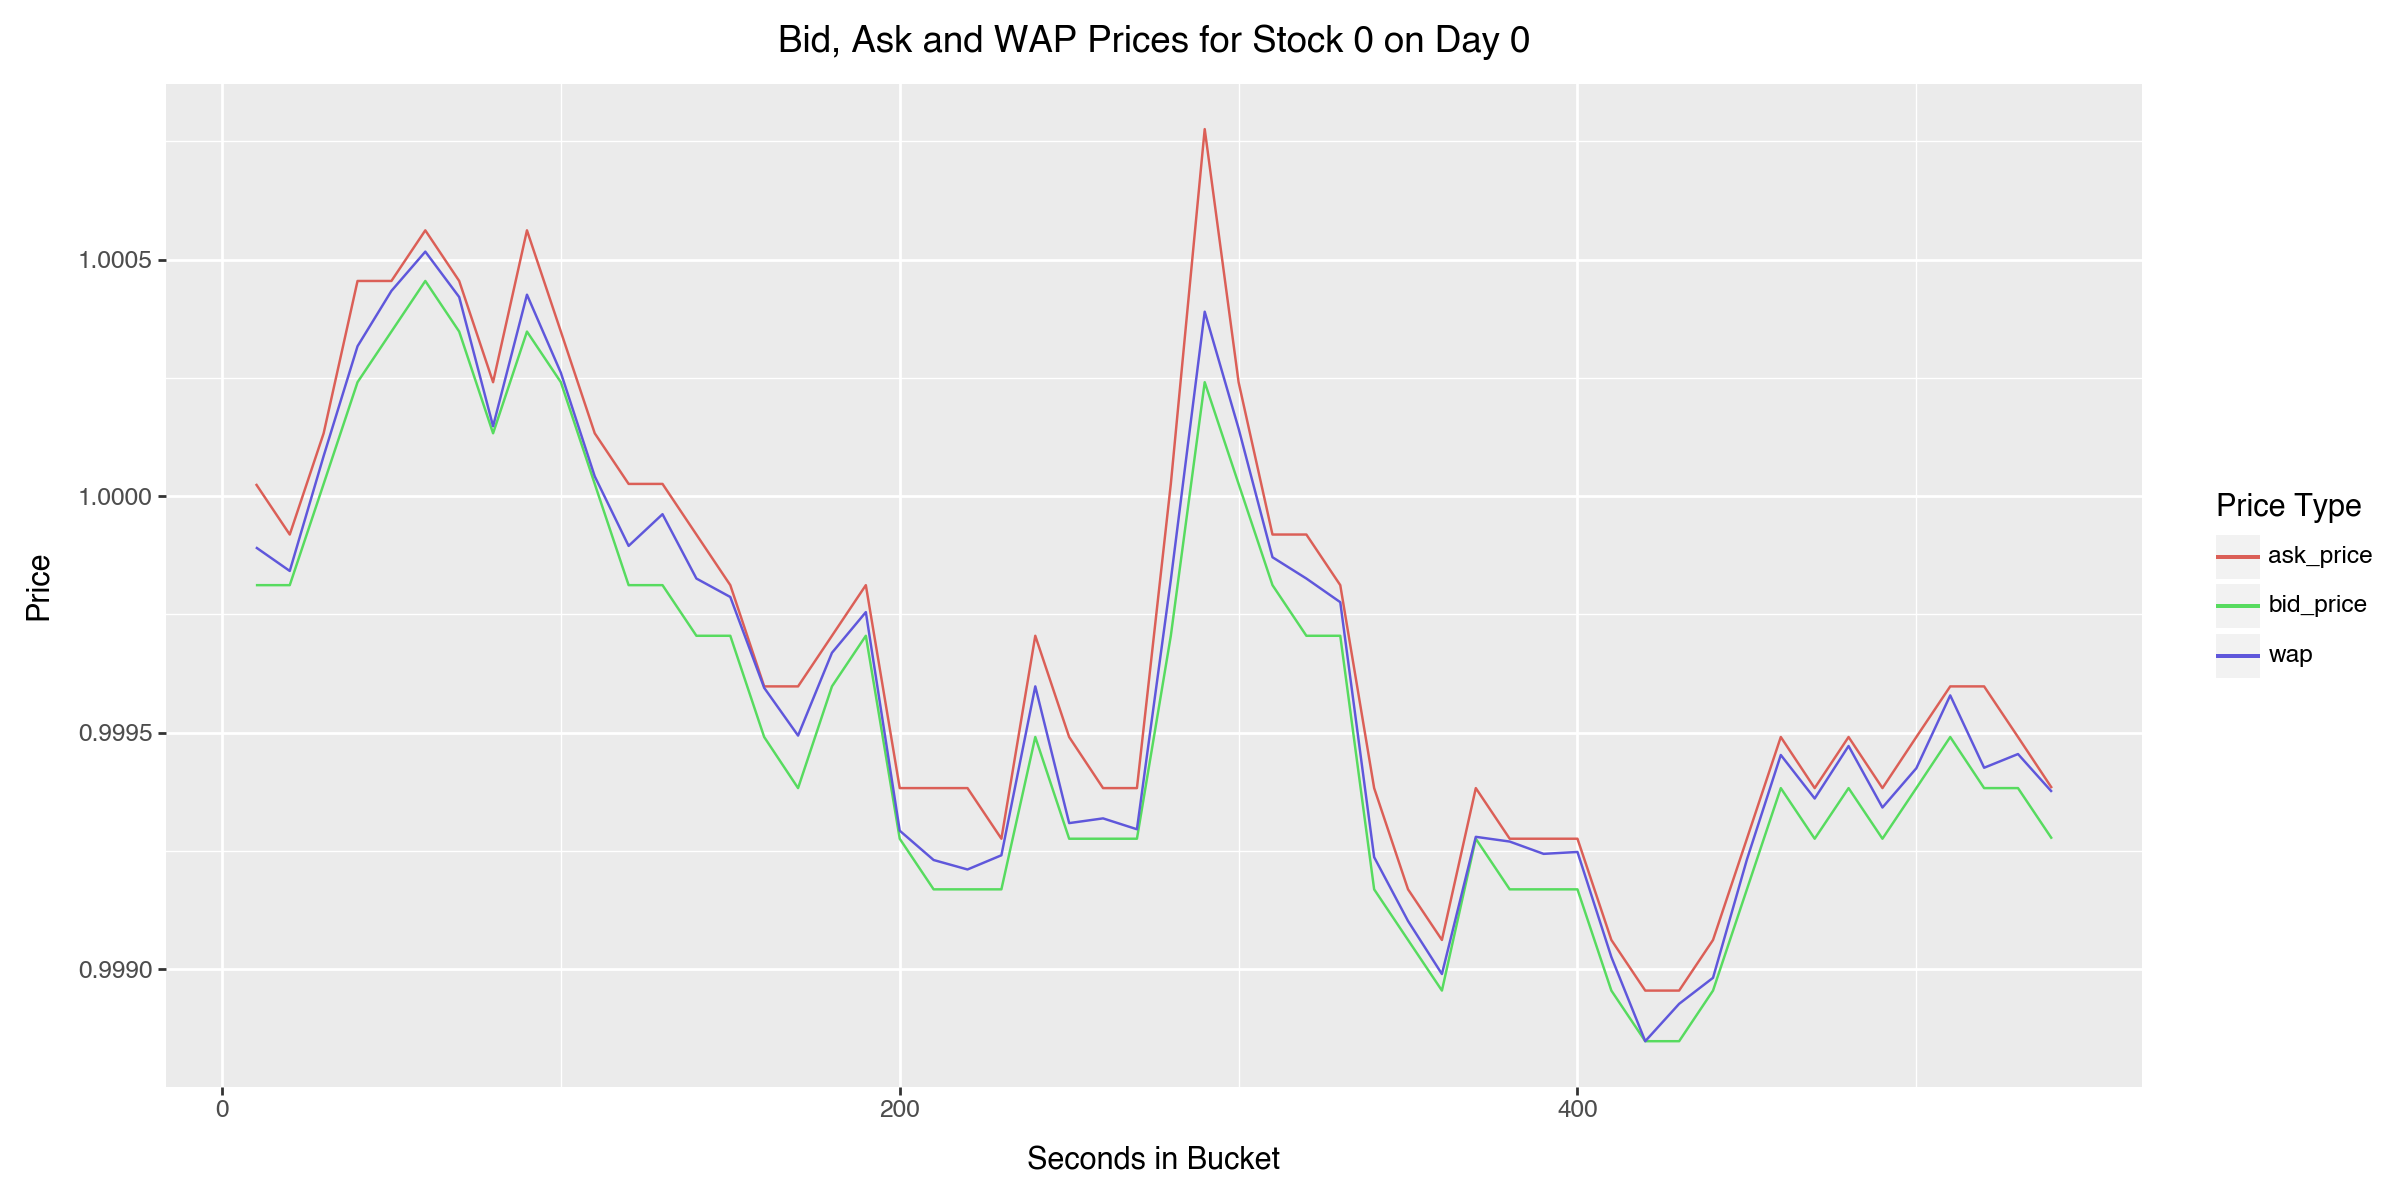

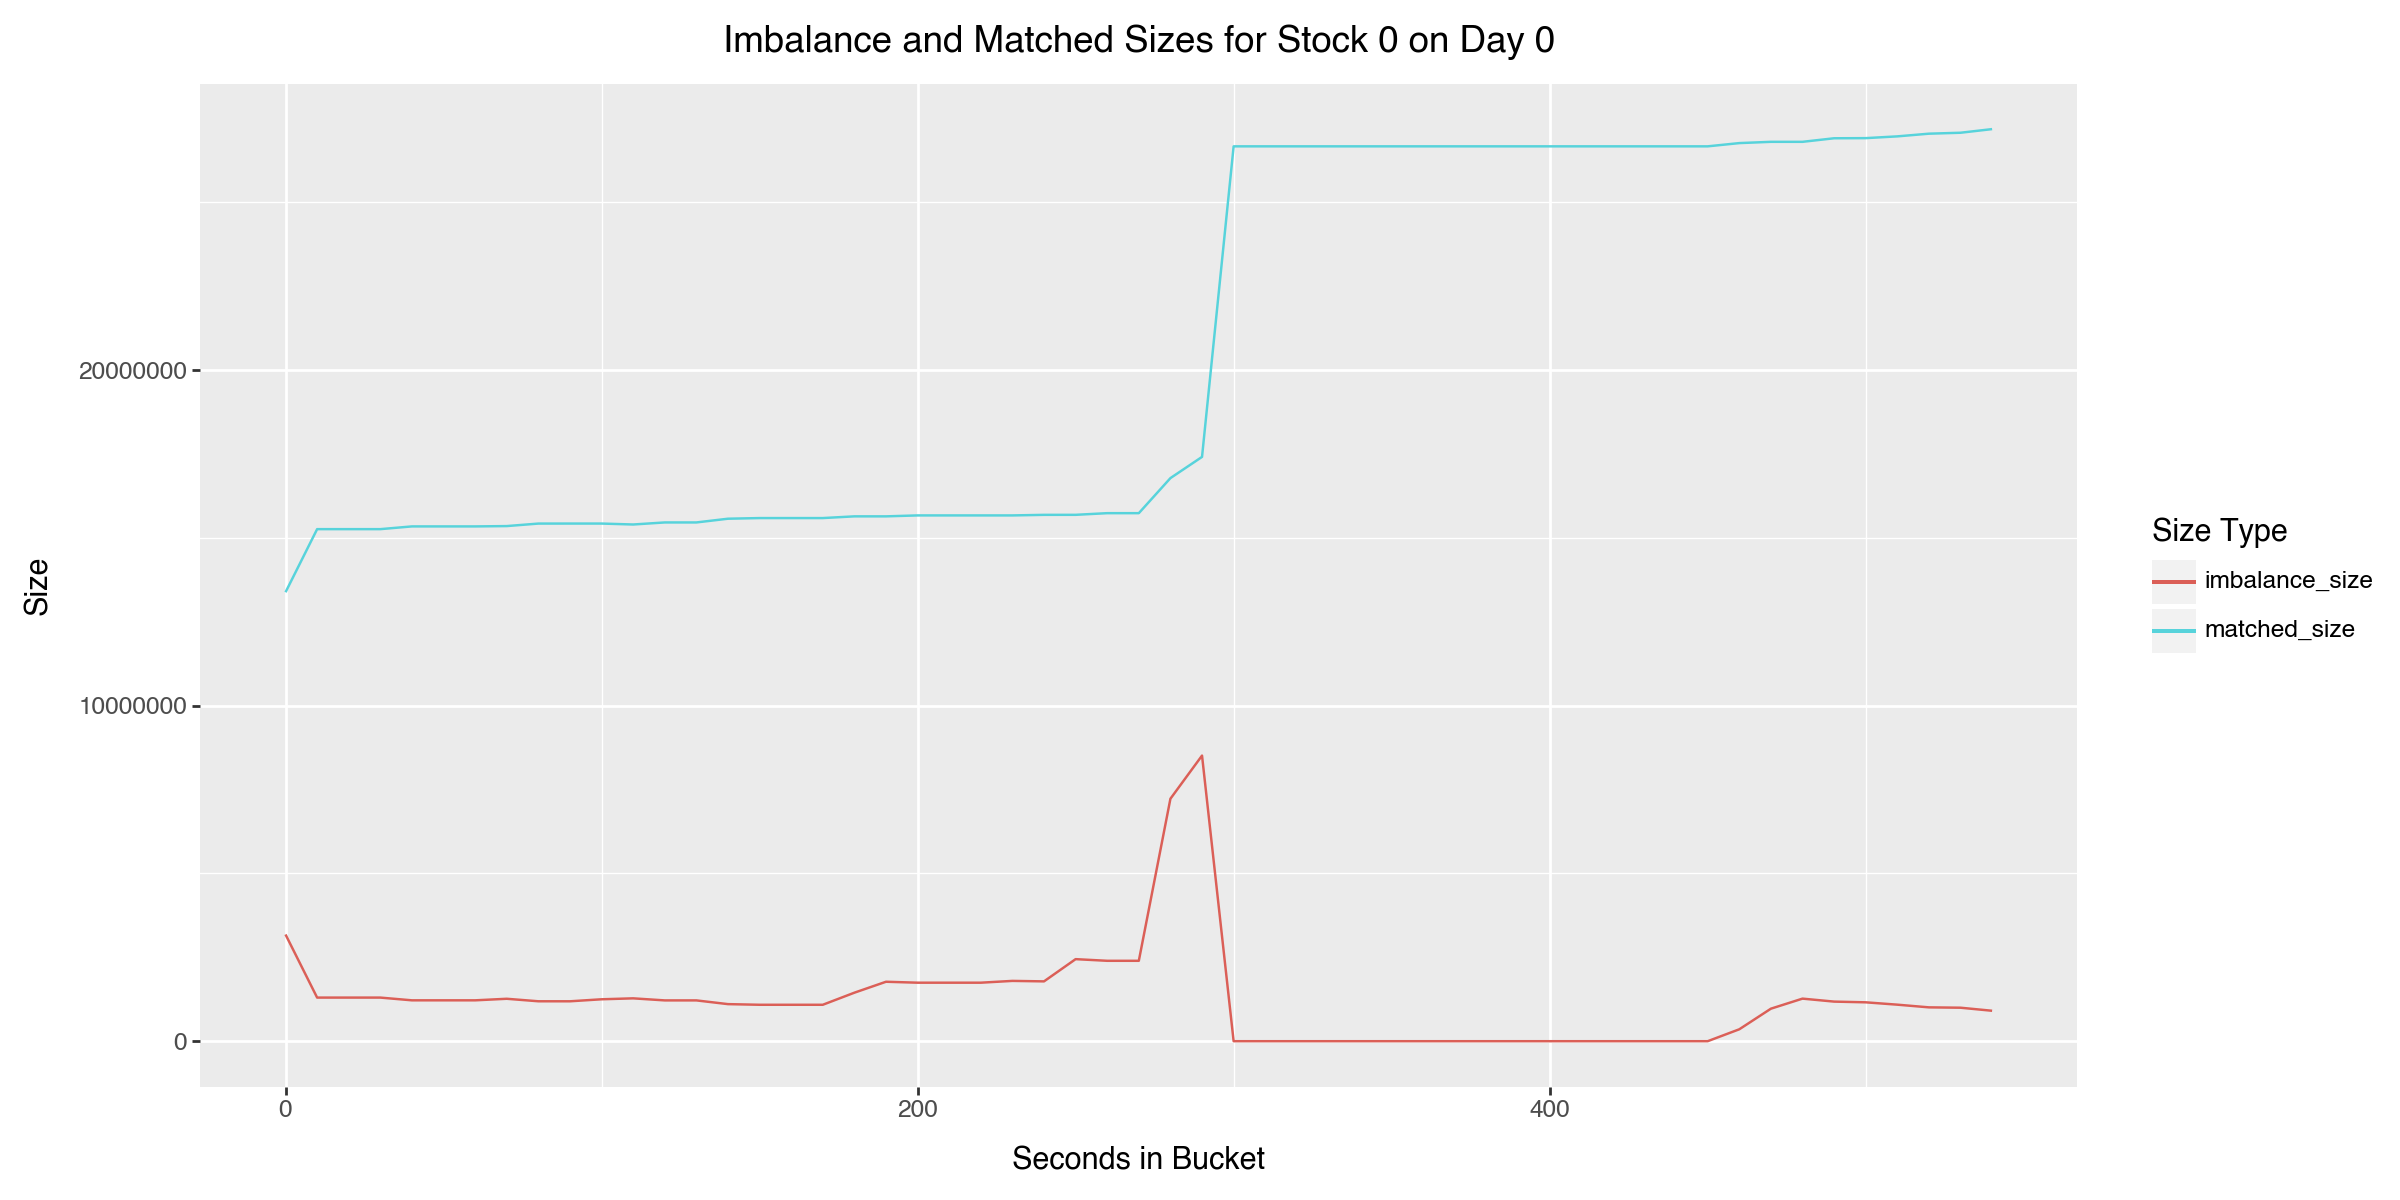

[01/13/25 17:47:35] WARNING  /Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-p ]8;id=404082;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=749486;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/warnings.py#112\112]8;;\
                             ackages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path:                  
                             Removed 30 rows containing missing values.                                            
                                                                                                                   

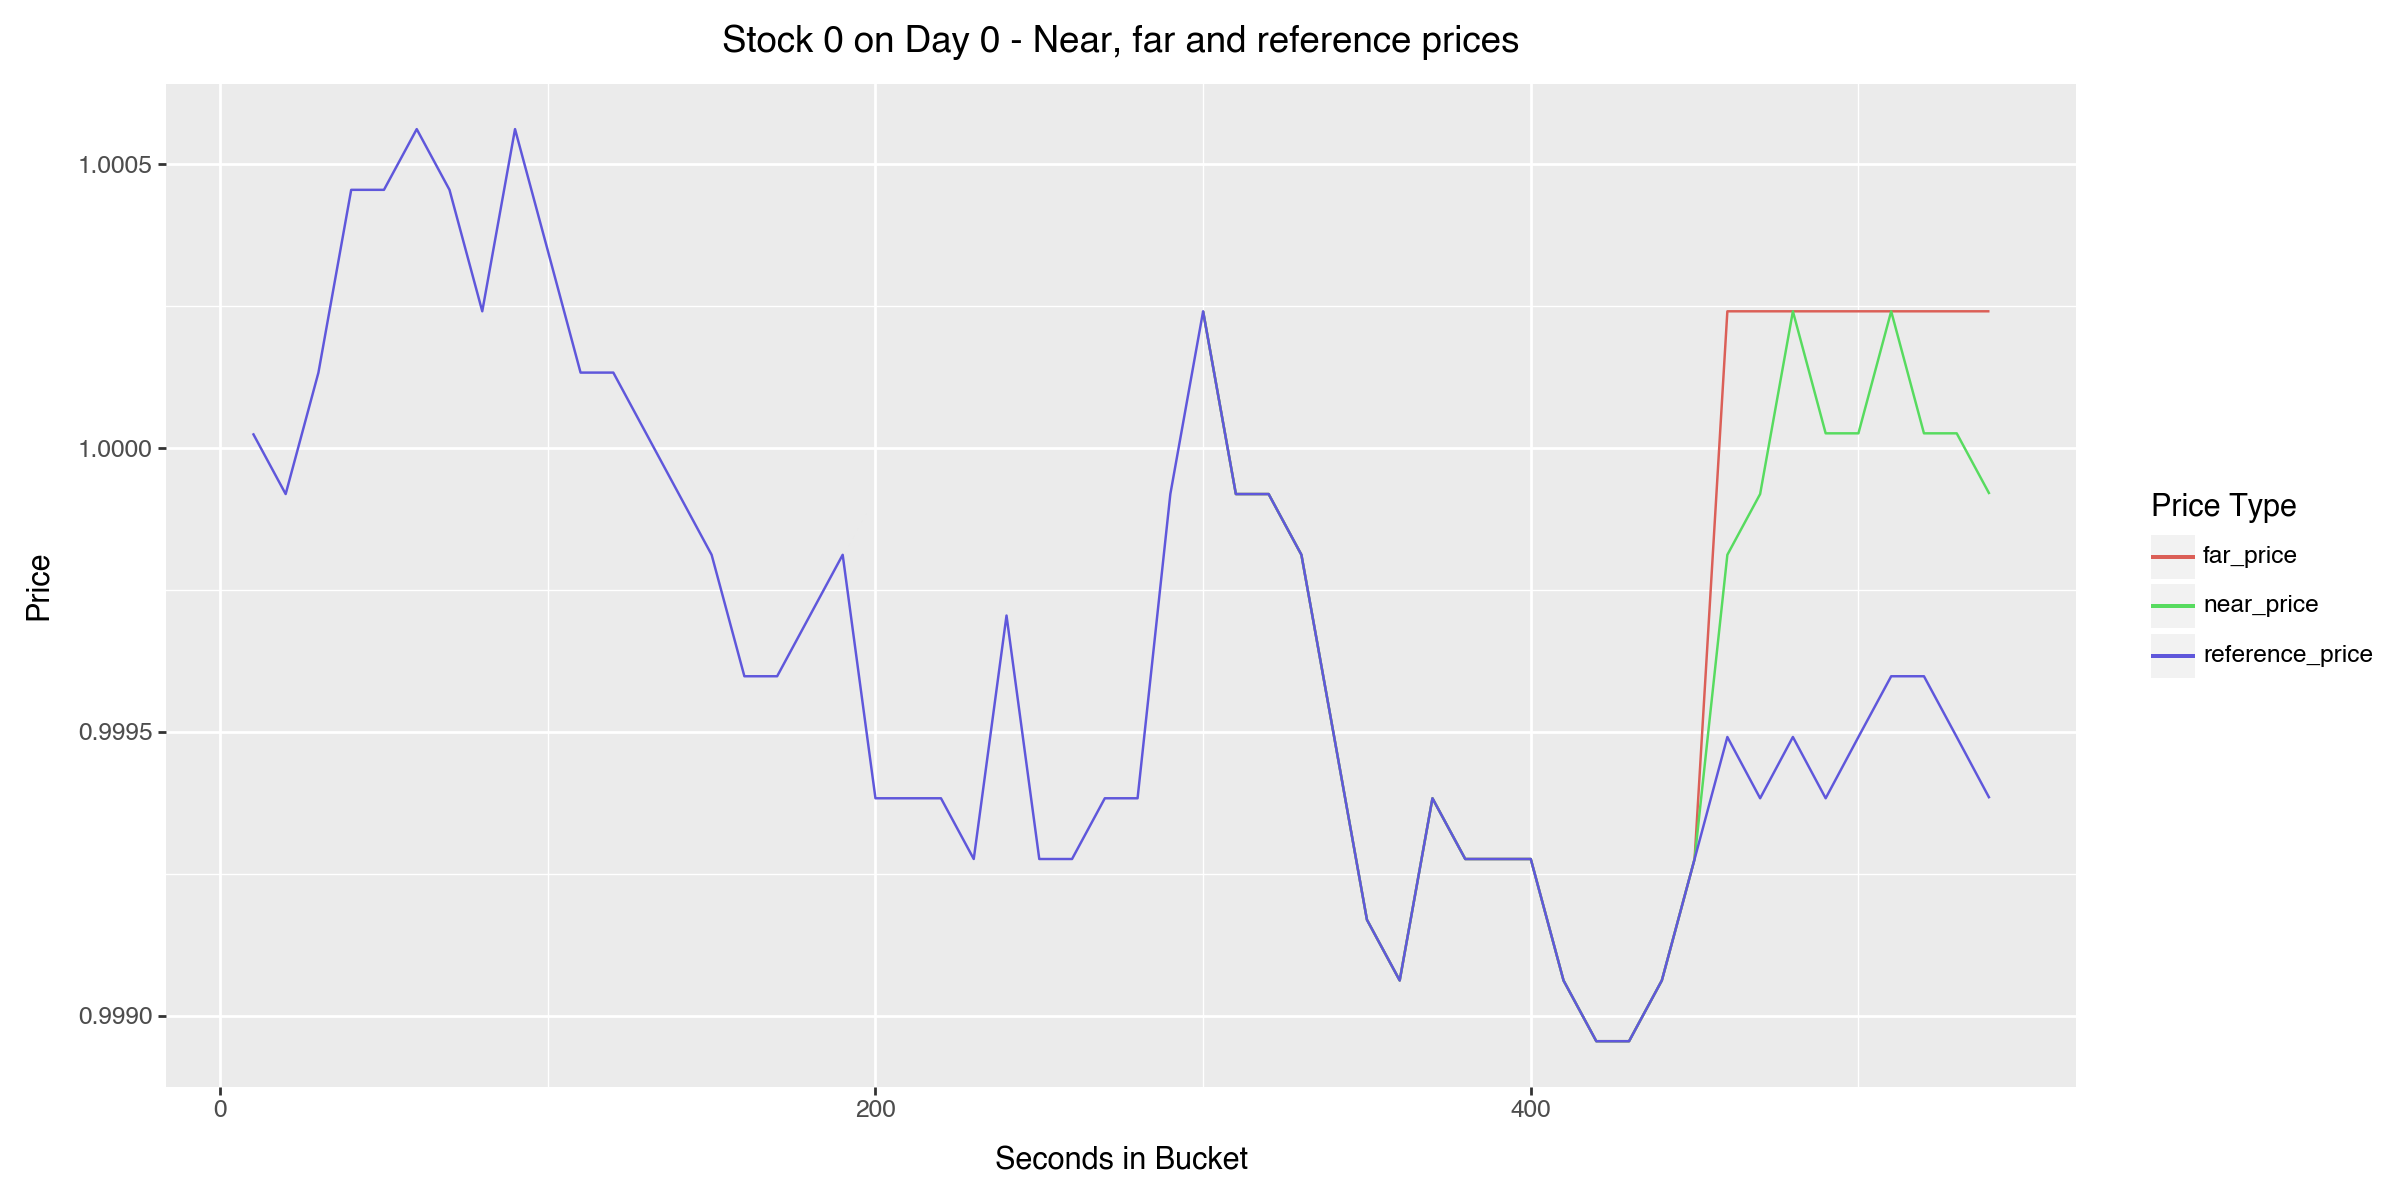

In [213]:
# Plotting time series for target in day 0

processed_train_data = catalog.load("raw_train_data")

processed_train_data[processed_train_data["date_id"] == 2]
plot_time_series(processed_train_data, date_id=2)


plots = plot_market_data(processed_train_data)
plots[0].show()
plots[1].show()
plots[2].show()

# Generate and display the plots
# histogram_plot = plot_all_histograms(data)

### Dataset inspection
* The dataset consists of only numeric features that can be used in the model
    + row_id, stock_id, time_id are used as identifiers for the final submission
    + target is the target variable
    + all other columns are used as features
    + moreover, we can construct more features that might be used for further alpha extraction
        + the whole point of this exercise is to predict the closing price (given by the specific formula from description)
        + if we can predict that alpha accurately, we can use it to trade the stock
        + for instance, by posting bids below / offers on non-primaries above expected value (e.g. TURQ vs LSE)
* Looks like there are no missing values for most columns in the dataset
   + the only columns with missing values are `far_price` (55.26%) and `near_price` (54.55%)

In [214]:
data = out0["raw_train_data"]

# Display data types of columns
# only numeric, no categorical features
sc.info("\nData types of columns:")
sc.info(data.dtypes)
sc.info("\nMissing values in each column:")
sc.info(data.isna().sum())
sc.info("\nMissing values percentage in each column:")
sc.info((data.isna().sum() / len(data) * 100).round(2))

# Display basic dataset information
sc.info("\nDataset Description:")
sc.info(f"Number of rows: {len(data)}")

sc.info(f"Number of columns: {len(data.columns)}")
sc.info("\nColumn descriptions:")
sc.info(data.describe())

                    INFO                                                                             ]8;id=883983;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py\746779995.py]8;;\:]8;id=59799;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py#5\5]8;;\
                             Data types of columns:                                                                

                    INFO     stock_id                     int64                                      ]8;id=614633;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py\746779995.py]8;;\:]8;id=414511;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py#6\6]8;;\
                             date_id                      int64                                                    
                             seconds_in_bucket            int64                                                    
                             imbalance_size             float64                                                    
                             imbalance_buy_sell_flag      int64                                                    
                             reference_price            float64                                                    
                             matched_size               float64                                                    
                             far_price                  float64                                                    
                             near_price                 float64                                                    
                             bid_price                  float64                                                    
                             bid_size                   float64                                                    
                             ask_price                  float64                                                    
                             ask_size                   float64                                                    
                             wap                        float64                                                    
                             target                     float64                                                    
                             time_id                      int64                                                    
                             row_id                      object                                                    
                             scale_imbalance_size       float64                                                    
                             scale_matched_size         float64                                                    
                             scale_bid_size             float64                                                    
                             scale_ask_size             float64                                                    
                             auc_bid_size               float64                                                    
                             auc_ask_size               float64                                                    
                             dtype: object                                                                         

                    INFO                                                                             ]8;id=79996;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py\746779995.py]8;;\:]8;id=14715;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py#7\7]8;;\
                             Missing values in each column:                                                        

                    INFO     stock_id                       0                                        ]8;id=206360;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py\746779995.py]8;;\:]8;id=264787;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py#8\8]8;;\
                             date_id                        0                                                      
                             seconds_in_bucket              0                                                      
                             imbalance_size                 2                                                      
                             imbalance_buy_sell_flag        0                                                      
                             reference_price                2                                                      
                             matched_size                   2                                                      
                             far_price                  28716                                                      
                             near_price                 28358                                                      
                             bid_price                      2                                                      
                             bid_size                       0                                                      
                             ask_price                      2                                                      
                             ask_size                       0                                                      
                             wap                            2                                                      
                             target                         0                                                      
                             time_id                        0                                                      
                             row_id                         0                                                      
                             scale_imbalance_size           2                                                      
                             scale_matched_size             2                                                      
                             scale_bid_size                 0                                                      
                             scale_ask_size                 0                                                      
                             auc_bid_size                   2                                                      
                             auc_ask_size                   2                                                      
                             dtype: int64                                                                          

                    INFO                                                                             ]8;id=168536;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py\746779995.py]8;;\:]8;id=549790;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py#9\9]8;;\
                             Missing values percentage in each column:                                             

...

                    INFO                                                                            ]8;id=625847;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py\746779995.py]8;;\:]8;id=304445;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py#13\13]8;;\
                             Dataset Description:                                                                  

                    INFO     Number of rows: 52379                                                  ]8;id=950429;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py\746779995.py]8;;\:]8;id=406167;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py#14\14]8;;\

                    INFO     Number of columns: 23                                                  ]8;id=364303;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py\746779995.py]8;;\:]8;id=11274;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py#16\16]8;;\

                    INFO                                                                            ]8;id=307646;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py\746779995.py]8;;\:]8;id=198162;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py#17\17]8;;\
                             Column descriptions:                                                                  

                    INFO                stock_id       date_id  seconds_in_bucket  imbalance_size   ]8;id=981956;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py\746779995.py]8;;\:]8;id=863563;file:///var/folders/_4/lvfgz8ld58b3qwkrcr3n3l_h0000gn/T/ipykernel_37350/746779995.py#18\18]8;;\
                             \                                                                                     
                             count  52379.000000  52379.000000       52379.000000    5.237700e+04                  
                             mean      99.528265    241.753775         271.330304    5.597872e+06                  
                             std       57.674525    138.475733         159.321278    1.950456e+07                  
                             min        0.000000      0.000000           0.000000    0.000000e+00                  
                             25%       50.000000    123.000000         130.000000    8.623290e+04                  
                             50%       99.000000    243.000000         270.000000    1.090886e+06                  
                             75%      149.000000    361.000000         410.000000    4.116365e+06                  
                             max      199.000000    480.000000         540.000000    1.393658e+09                  
                                                                                                                   
                                    imbalance_buy_sell_flag  reference_price  matched_size                         
                             far_price  \                                                                          
                             count             52379.000000     52377.000000  5.237700e+04                         
                             23663.000000                                                                          
                             mean                 -0.019359         1.000000  4.498678e+07                         
                             0.999849                                                                              
                             std                   0.885977         0.002534  1.426764e+08                         
                             0.019483                                                                              
                             min                  -1.000000         0.962276  9.761950e+03                         
                             0.000934                                                                              
                             25%                  -1.000000         0.998762  5.348968e+06                         
                             0.996409                                                                              
                             50%                   0.000000         0.999988  1.296209e+07                         
                             0.999940                                                                              
                             75%                   1.000000         1.001187  3.265964e+07                         
                             1.003251                                                                              
                             max                   1.000000         1.036497  7.687153e+09                         
                             1.248431                                                                              
                                                                                                                   
                                      near_price     bid_price  ...      ask_size           wap  \                 
                             count  24021.000000  52377.000000  ...  5.237900e+04  52377.000000                    
                             mean       0.999720      0.999733  ...  5.

#### Plot feature distributions

[01/13/25 17:47:37] WARNING  /Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-p ]8;id=539606;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=576953;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/warnings.py#112\112]8;;\
                             ackages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed                
                             57094 rows containing non-finite values.                                              
                                                                                                                   

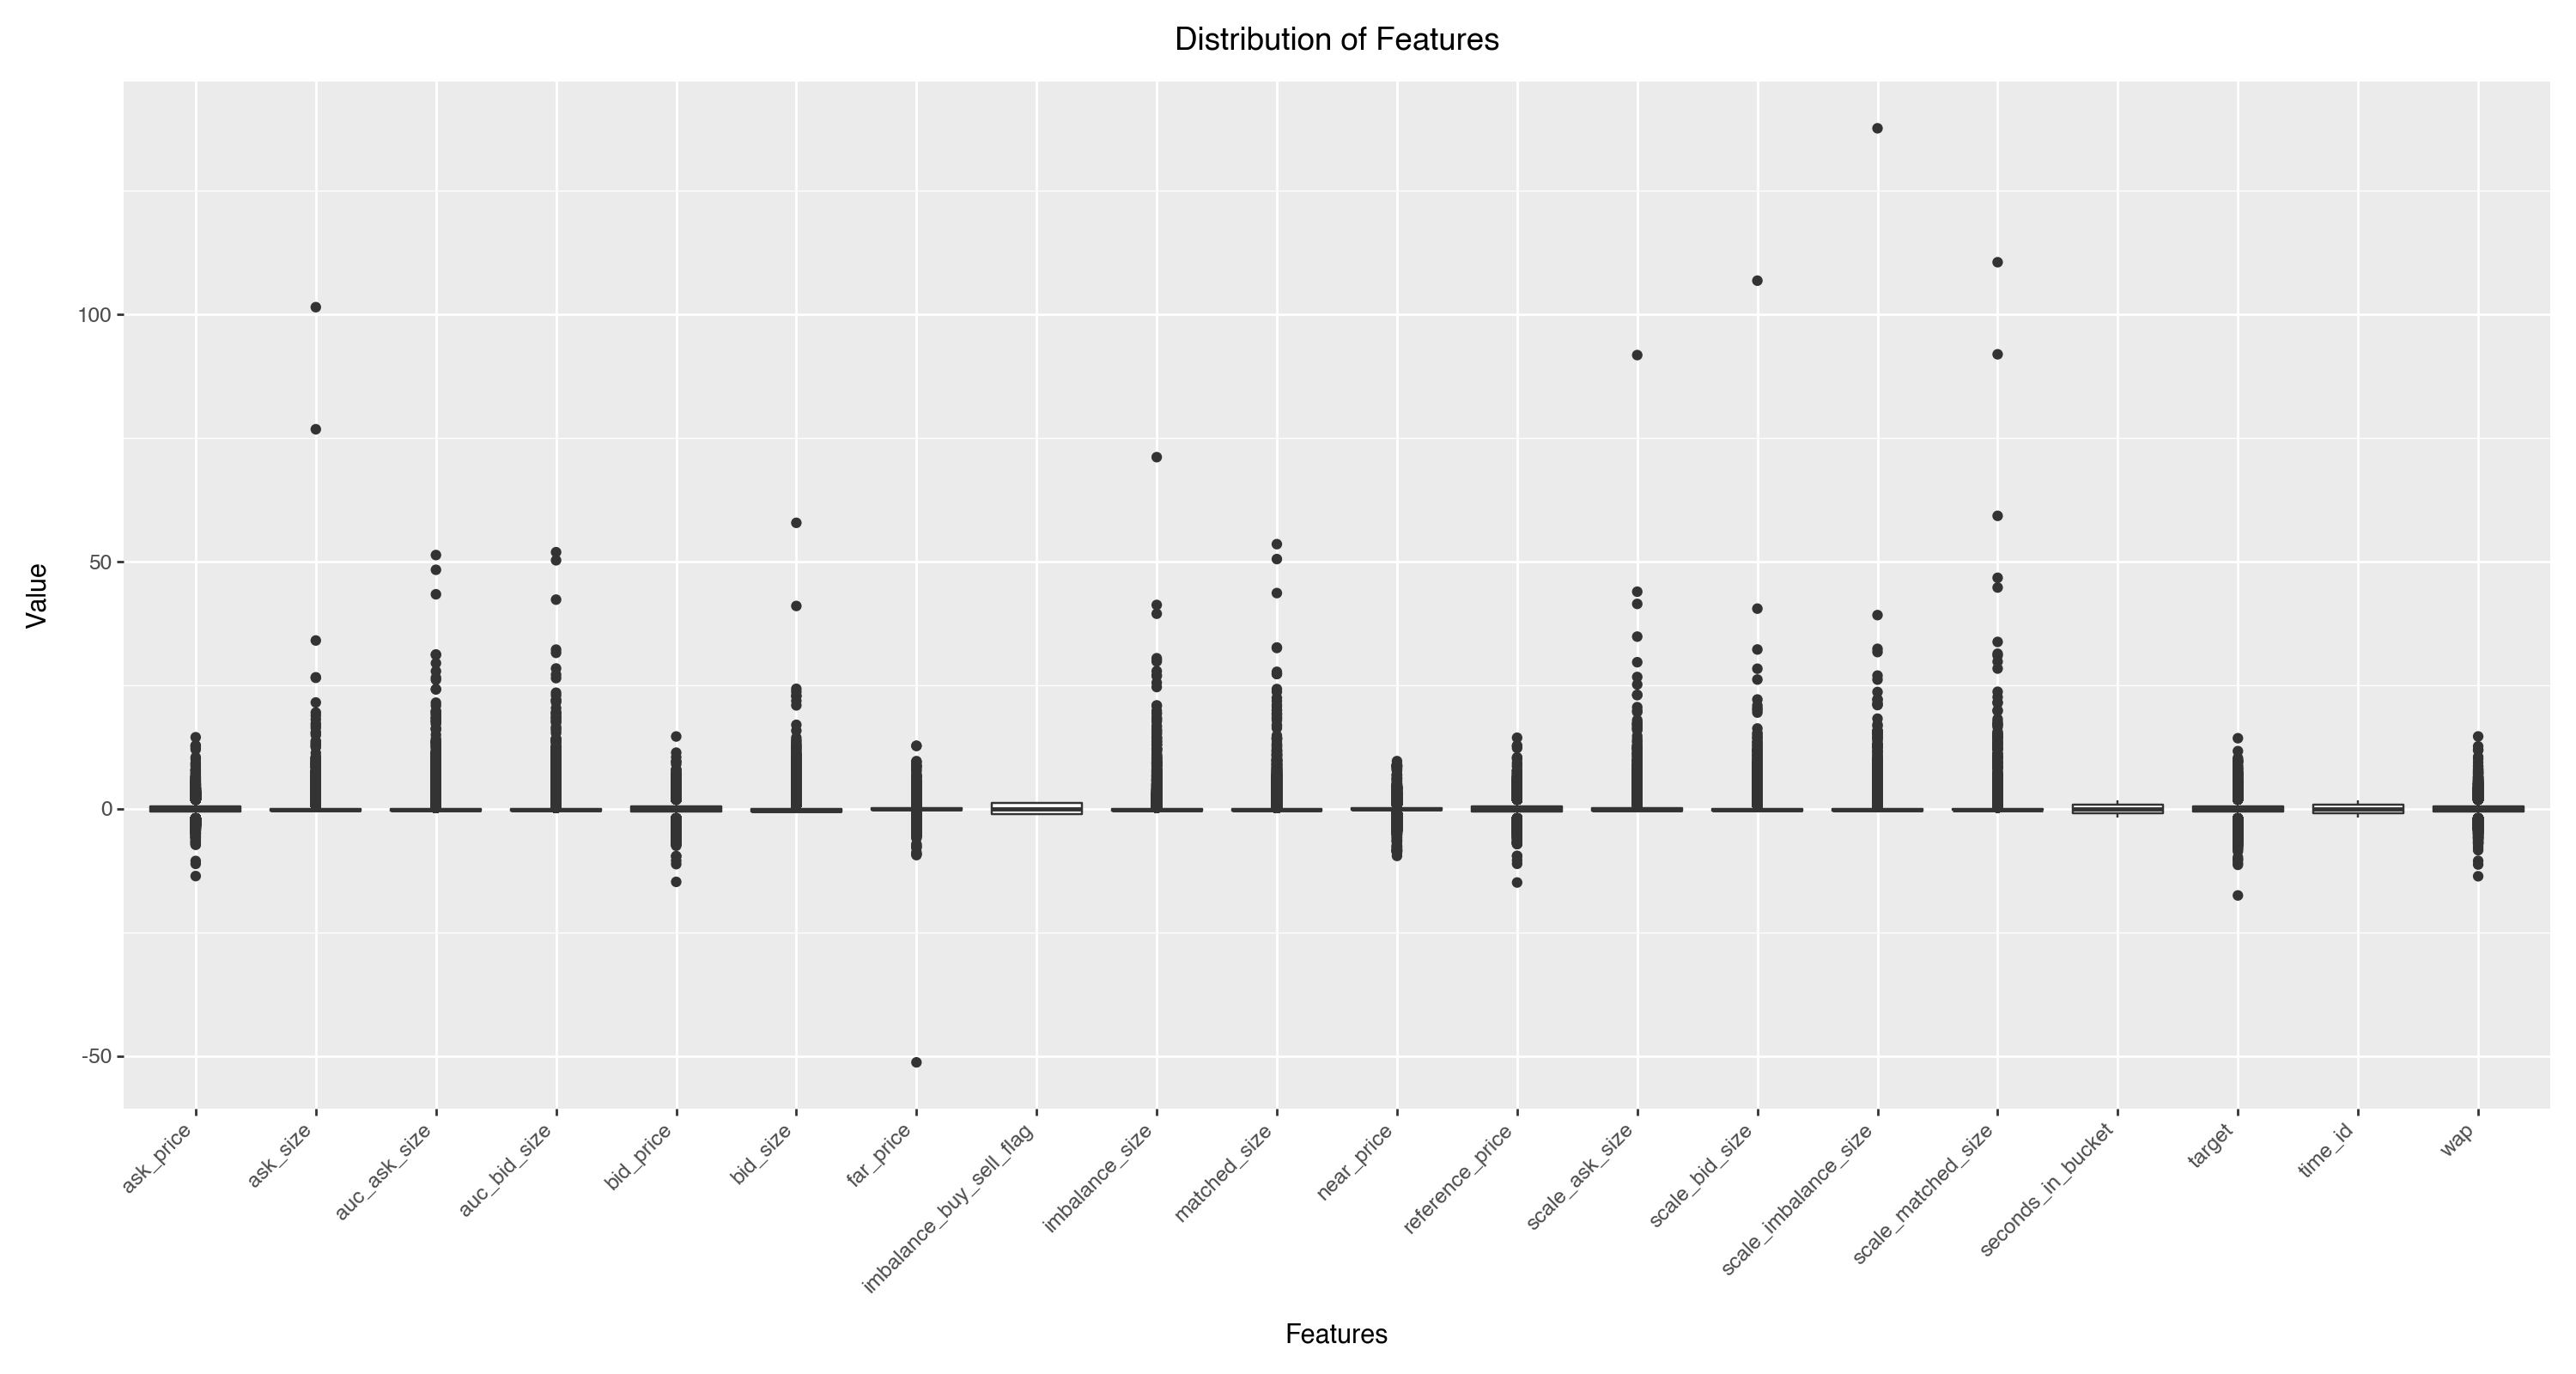

In [215]:
# Initial feature distributions vary by magnitude and scale. Hence, further
# normalization might be required
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    p1 = plot_feature_distributions(data, normalize=True)
p1
# PlotnineWarning: stat_boxplot : Removed    57094 rows containing non-finite values has been removed from the plot

* each feature is plotted against the target variable
* we can clearly see outliers in the data
plot_feature_relationships(data.sample(frac=0.01), data.columns.tolist(), "target")

#### Plot correlation matrix
* there is a strong correlation between some of the features
    + partially, it comes from the fact that some features are a linear combination of others
    + e.g. `scale_bid_size` and `scale_ask_size` vs `bid_size` and `ask_size`

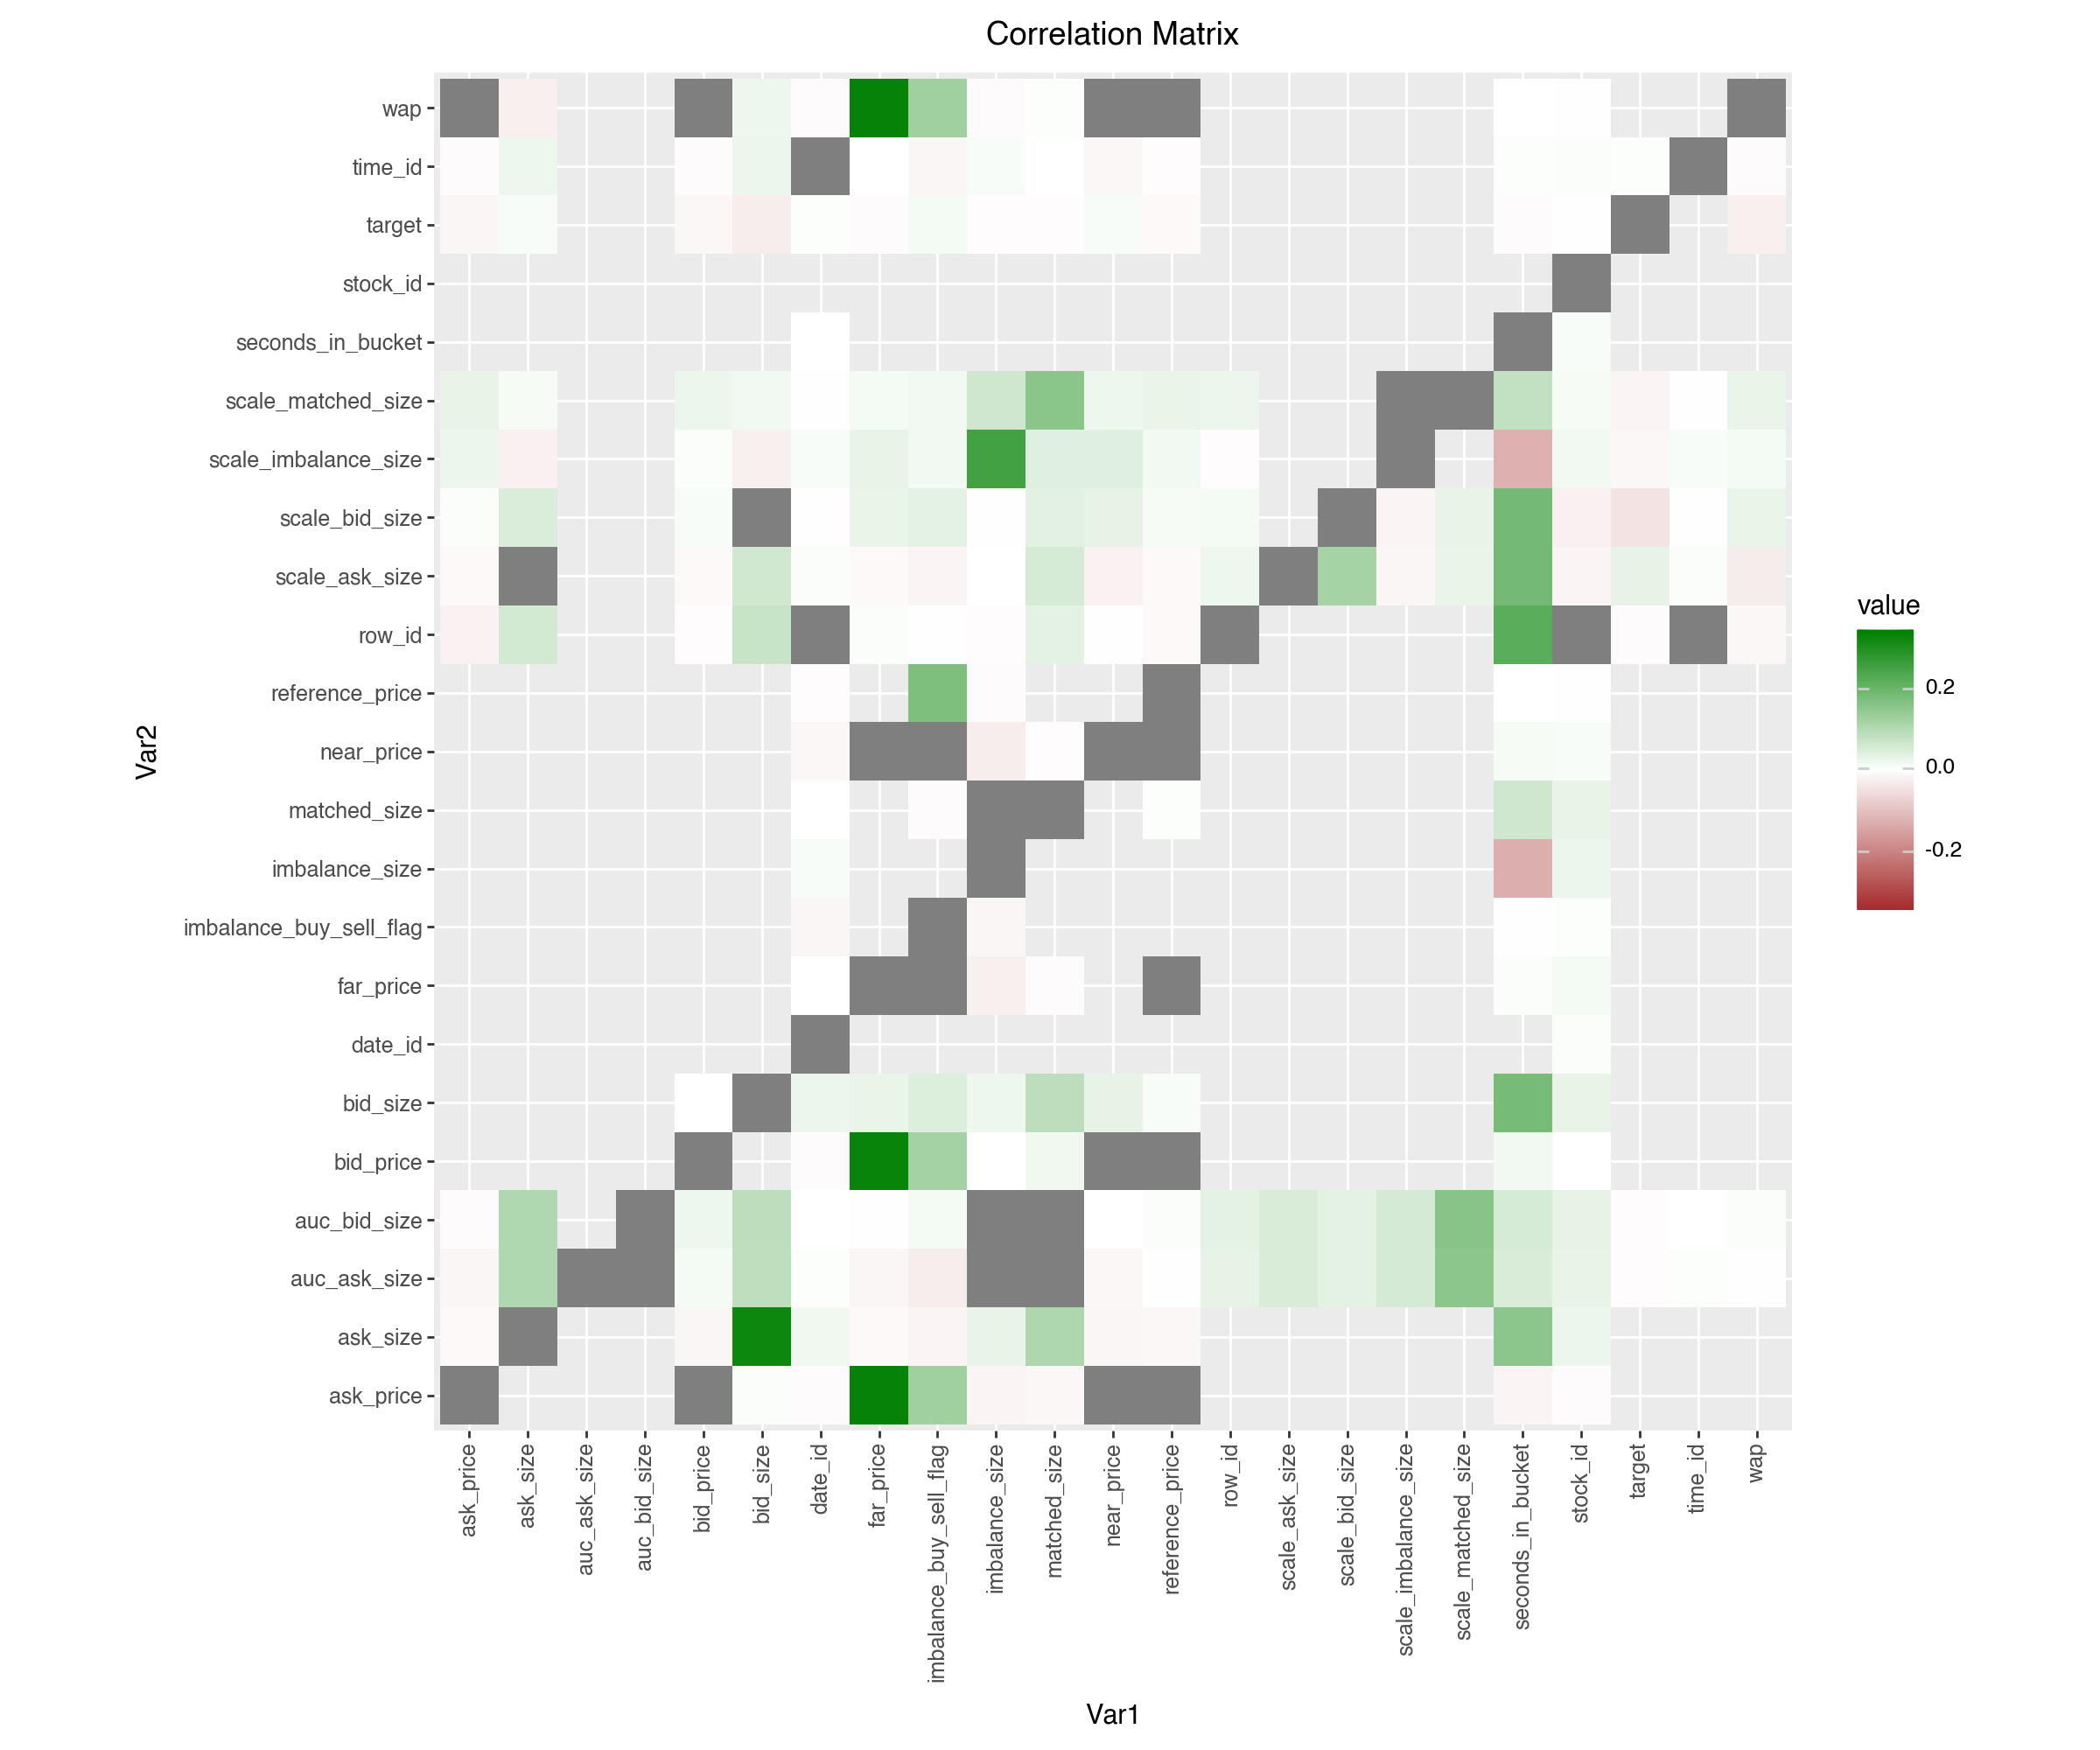

In [216]:
plot_correlation_matrix(data)

## Feature engineering
This node generates features for the model

Generate features for training with formulas in LaTeX notation:

### Basic Features:
- Ask Money: $$AM = AS \times AP$$
- Bid Money: $$BM = BS \times BP$$
- Ask Size All: $$ASA = AS + AAS$$
- Bid Size All: $$BSA = BS + ABS$$
- Volume Size All: $$VSA = ASA + BSA$$
- Ask Auction Money: $$AAM = RP \times AAS$$
- Bid Auction Money: $$BAM = RP \times ABS$$
- Volume Money: $$VM = AM + BM$$
- Volume Continuous: $$VC = AS + BS$$
- Diff Ask Bid Size: $$DABS = AS - BS$$
- Volume Auction: $$VA = IS + 2MS$$
- Volume Auction Money: $$VAM = VA \times RP$$
- Mid Price: $$MP = \frac{AP + BP}{2}$$
- Mid Price Near Far: $$MPNF = \frac{NP + FP}{2}$$
- Price Diff Ask Bid: $$PDAB = AP - BP$$
- Price Div Ask Bid: $$PDAB = \frac{AP}{BP}$$
- Flag Scale Imbalance Size: $$FSIS = IBSF \times SIS$$
- Flag Imbalance Size: $$FIS = IBSF \times IS$$
- Div Flag Imbalance Size to Balance: $$DFISB = \frac{IS}{MS} \times IBSF$$
- Price Pressure: $$PP = PDAB \times IS$$
- Price Pressure v2: $$PPv2 = PP \times IBSF$$
- Depth Pressure: $$DP = \frac{DABS}{FP - NP}$$
- Div Bid Size Ask Size: $$DBSAS = \frac{BS}{AS}$$

### Ratio Features:
For any pair $(X,Y)$ in ratio pairs:
$$div\\_X\\_Y = \frac{X}{Y}$$

### Imbalance Features:
For any pair $(X,Y)$ in imbalance pairs:
$$imb1\\_X\\_Y = \frac{X-Y}{X+Y}$$
Price Imbalance Features:
For any pair of prices $(P1,P2)$:
$imb1\_P1\_P2 = \frac{P1-P2}{P1+P2}$

### Market Urgency Features:
- Market Urgency v2: $$MUv2 = (IASBS + 2)(IAPBP + 2)(IAASABS + 2)$$
- Market Urgency: $$MU = PDAB \times IASBS$$
- Market Urgency v3: $$MUv3 = IAPBP \times IASBS$$

### Rolling Features:
For each feature $F$ and window size $w$:
- Rolling Mean: $$\bar{F_w} = \frac{1}{w}\sum_{i=t-w+1}^t F_i$$
- Rolling Std: $$\sigma_{F_w} = \sqrt{\frac{1}{w}\sum_{i=t-w+1}^t (F_i - \bar{F_w})^2}$$

Where:
* $AS$ = ask_size,
* $AP$ = ask_price,
* $BS$ = bid_size,
* $BP$ = bid_price
* $AAS$ = auc_ask_size,
* $ABS$ = auc_bid_size,
* $RP$ = reference_price
* $IS$ = imbalance_size,
* $MS$ = matched_size,
* $NP$ = near_price
* $FP$ = far_price,
* $IBSF$ = imbalance_buy_sell_flag
* $SIS$ = scale_imbalance_size
* $IASBS$ = imb1_ask_size_bid_size
* $IAPBP$ = imb1_ask_price_bid_price
* $IAASABS$ = imb1_auc_ask_size_auc_bid_size

In [217]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    out1 = (
        pipelines["data_processing"]
        .nodes[1]
        .run({"raw_train_data": out0["raw_train_data"]})
    )
processed_train_data = out1["processed_train_data"]
feature_list = out1["feature_list"]

[01/13/25 17:47:39] INFO     Running node: generate_features: generate_features([raw_train_data]) ->    ]8;id=403410;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py\node.py]8;;\:]8;id=420257;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py#367\367]8;;\
                             [processed_train_data;feature_list]                                                   

#### Handling missing values / outliers / uncalculated values
* NaN values are dropped
* Infinity values are replaced with mean values for the column

In [218]:
out2 = (
    pipelines["data_processing"]
    .nodes[2]
    .run(
        {
            "processed_train_data": processed_train_data,
        }
    )
)

processed_train_data_no_nan = out2["processed_train_data_no_nan"]

[01/13/25 17:47:40] INFO     Running node: handle_nan_rows: handle_nan_rows([processed_train_data]) ->  ]8;id=697341;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py\node.py]8;;\:]8;id=747619;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py#367\367]8;;\
                             [processed_train_data_no_nan]                                                         

In [219]:
out3 = (
    pipelines["data_processing"]
    .nodes[3]
    .run(
        {
            "processed_train_data_no_nan": processed_train_data_no_nan,
        }
    )
)

                    INFO     Running node: check_and_replace_infinity_values:                           ]8;id=689370;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py\node.py]8;;\:]8;id=751397;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py#367\367]8;;\
                             check_and_replace_infinity_values([processed_train_data_no_nan]) ->                   
                             [processed_train_data_no_nan_no_inf]                                                  

                    WARNING  /Users/krzysztofwojdalski/github_projects/optiver/src/optiver/pipeline ]8;id=48336;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=672893;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/warnings.py#112\112]8;;\
                             s/data_processing/nodes.py:215: SettingWithCopyWarning:                               
                             A value is trying to be set on a copy of a slice from a DataFrame.                    
                             Try using .loc[row_indexer,col_indexer] = value instead                               
                                                                                                                   
                             See the caveats in the documentation:                                                 
                             https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#                
                             returning-a-view-versus-a-copy                                                        
                                                                                                                   

                    WARNING  Infinity values have been replaced with column means                      ]8;id=663875;file:///Users/krzysztofwojdalski/github_projects/optiver/src/optiver/pipelines/data_processing/nodes.py\nodes.py]8;;\:]8;id=207634;file:///Users/krzysztofwojdalski/github_projects/optiver/src/optiver/pipelines/data_processing/nodes.py#218\218]8;;\

### Feature selection
#### Description
We used the same set of tests as during the classes. As below:
* Variance thresholding helps identify and remove features that show minimal variation across observations.
* When a feature remains mostly constant or changes very little, it typically doesn't contribute meaningful
predictive power.
* Moreover, I use mi_score and sign_fscore to identify features with weak relationships with the target variable.
Features with low mi_score ($mi\_score < 0.01$) and high sign_fscore ($sign\_fscore > 0.1$)
should be removed as they have weak relationships with the target variable.

In [220]:
all_features = initial_features + feature_list
# Remove submission features from all features
all_features = [f for f in all_features if f not in params["submission_features"]]
proc_df = out3["processed_train_data_no_nan_no_inf"]
proc_df[all_features]

,seconds_in_bucket,imbalance_size,imbalance_buy_sell_flag,reference_price,matched_size,far_price,near_price,bid_price,bid_size,ask_price,...,div_flag_imbalance_size_2_balance,ask_price,imb1_reference_price_bid_price,scale_matched_size,imb1_near_price_wap,volume_auc_money,imb1_far_price_wap,bid_size,scale_bid_size,bid_size_all
419885,410,0.00,0,1.002468,4.790914e+06,1.002468,1.002468,1.000728,336449.12,1.002468,...,0.000000,1.002468,0.000869,2.366042,0.000001,9.605477e+06,0.000001,336449.12,41.226963,5.127364e+06
4914923,340,0.00,0,0.994270,1.794732e+05,0.994270,0.994270,0.994270,228372.00,0.998413,...,0.000000,0.998413,0.000000,0.581974,-0.001910,3.568896e+05,-0.001910,228372.00,1.949467,4.078452e+05
1987607,500,0.00,0,0.996321,1.379012e+08,0.996321,0.996321,0.996070,11911.00,0.996405,...,0.000000,0.996405,0.000126,8.390252,0.000024,2.747877e+08,0.000024,11911.00,0.856266,1.379131e+08
316071,520,1979400.85,-1,1.002263,8.021264e+07,1.001141,1.001857,1.002215,177978.24,1.002502,...,-0.024677,1.002502,0.000024,2.205592,-0.000319,1.627722e+08,-0.000676,177978.24,12.342252,8.039062e+07
1641438,540,0.00,0,1.001581,9.588819e+07,1.001581,1.001581,1.001581,37356.90,1.001694,...,0.000000,1.001694,0.000000,1.057883,-0.000034,1.920796e+08,-0.000034,37356.90,2.154914,9.592554e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136833,530,0.00,0,0.997146,1.284065e+07,0.997146,0.997146,0.997146,12535.25,0.997291,...,0.000000,0.997291,0.000000,0.909979,-0.000021,2.560800e+07,-0.000021,12535.25,0.885883,1.285318e+07
1522178,540,514094.70,1,0.998936,7.593380e+06,0.999470,0.999470,0.998492,45685.75,0.999292,...,0.067703,0.999292,0.000222,3.350260,0.000124,1.568415e+07,0.000124,45685.75,4.898320,8.153160e+06
3089549,340,440171.67,-1,0.996802,2.188302e+07,0.993767,0.995935,0.996802,37243.80,0.997236,...,-0.020115,0.997236,0.000000,1.316147,-0.000486,4.406485e+07,-0.001575,37243.80,0.675903,2.192027e+07
1539905,340,0.00,0,1.004233,1.276619e+08,1.004233,1.004233,1.004023,215285.16,1.004233,...,0.000000,1.004233,0.000105,1.092673,0.000051,2.564045e+08,0.000051,215285.16,0.995666,1.278772e+08


In [221]:
def calculate_feature_importance(
    proc_df: pd.DataFrame, features: list[str]
) -> tuple[pd.DataFrame, list[str]]:
    """Calculate feature importance scores using mutual information and f-regression.

    Args:
        proc_df: Processed dataframe containing features and target
        features: List of all feature names

    Returns:
        Tuple containing:
        - DataFrame with mutual information and f-regression scores for each feature
        - List of columns that should be dropped due to low importance
    """
    # Calculate mutual information scores
    sel = VarianceThreshold(0.01)
    sel_var = sel.fit_transform(proc_df[all_features])
    col_imp = proc_df[all_features][
        proc_df[all_features].columns[sel.get_support(indices=True)]
    ].columns
    col_redundant = set(processed_train_data[all_features].columns.tolist()) - set(
        col_imp
    )

    mi: dict[str, float] = dict()
    for feature in col_imp:
        mi.update(
            {
                feature: mutual_info_regression(
                    proc_df[[feature]].values, proc_df["target"].values
                )[0]
            }
        )
    miDF = pd.DataFrame.from_dict(mi, orient="index", columns=["score"])
    general_ranking = pd.DataFrame(index=all_features)
    general_ranking = pd.merge(general_ranking, miDF, left_index=True, right_index=True)
    general_ranking.rename(columns={"score": "mi_score"}, inplace=True)

    # Calculate f-regression scores
    warnings.simplefilter(action="ignore", category=FutureWarning)
    fscore: dict[str, float] = dict()
    for i in all_features:
        fscore.update(
            {i: f_regression(proc_df[[i]].values, proc_df["target"].values)[1]}
        )
    fscoreDF = pd.DataFrame.from_dict(fscore, orient="index", columns=["p_value_score"])
    fscoreDF.sort_values(by="p_value_score").head(10)
    fscoreDF.sort_values(by="p_value_score", ascending=False).head(10)
    fscoreDF["sign"] = np.where(fscoreDF.p_value_score < 0.1, 1, 0)
    general_ranking = pd.merge(
        general_ranking, fscoreDF, left_index=True, right_index=True
    )
    general_ranking.rename(
        columns={"p_value_score": "sign_fscore", "sign": "sign_fscore_0_1"},
        inplace=True,
    )

    # Identify columns to drop based on importance thresholds
    columns_to_drop = general_ranking[
        (general_ranking["mi_score"] < 0.01) & (general_ranking["sign_fscore"] > 0.1)
    ].index.tolist()

    return general_ranking, columns_to_drop


general_ranking, columns_to_drop = calculate_feature_importance(proc_df, all_features)

### Split the data into train and test
* Training and testing data is split into 80% and 20% of the data respectively.
    + This comes from the fact that dataset is large enough. There's no need to split it in a non-vanilla way

In [222]:
out4 = (
    pipelines["data_processing"]
    .nodes[4]
    .run(
        {
            "processed_train_data_no_nan": processed_train_data_no_nan,
            "params:test_size": params["test_size"],
            "params:random_state": params["random_state"],
            "params:target": params["target"],
        }
    )
)

X_train, X_test, y_train, y_test = (
    out4["X_train"],
    out4["X_test"],
    out4["y_train"],
    out4["y_test"],
)

[01/13/25 17:47:42] INFO     Running node: split_data_node:                                             ]8;id=993382;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py\node.py]8;;\:]8;id=386136;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py#367\367]8;;\
                             split_data([processed_train_data_no_nan;params:target;params:test_size;par            
                             ams:random_state]) -> [X_train;X_test;y_train;y_test]                                 

### Train KNN models with k-fold CV

In [223]:
out5 = (
    pipelines["data_processing"]
    .nodes[5]
    .run(
        {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
        }
    )
)

                    INFO     Running node: train_knn_model:                                             ]8;id=746900;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py\node.py]8;;\:]8;id=546608;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py#367\367]8;;\
                             train_knn_model([X_train;X_test;y_train;y_test]) -> [knn_model]                       

### Train Linear Regression models with k-fold CV

In [224]:
out6 = (
    pipelines["data_processing"]
    .nodes[6]
    .run(
        {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
        }
    )
)

[01/13/25 17:47:43] INFO     Running node: train_linear_model:                                          ]8;id=213665;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py\node.py]8;;\:]8;id=319420;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py#367\367]8;;\
                             train_linear_model([X_train;X_test;y_train;y_test]) -> [lr_model]                     

[01/13/25 17:47:44] WARNING  /Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-p ]8;id=922736;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=868591;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/warnings.py#112\112]8;;\
                             ackages/sklearn/base.py:486: UserWarning: X has feature names, but                    
                             LinearRegression was fitted without feature names                                     
                                                                                                                   

### Train SVR models with k-fold CV

In [225]:
out7 = (
    pipelines["data_processing"]
    .nodes[7]
    .run(
        {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
        }
    )
)

                    INFO     Running node: train_svr_model:                                             ]8;id=588044;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py\node.py]8;;\:]8;id=280337;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-packages/kedro/pipeline/node.py#367\367]8;;\
                             train_svr_model([X_train;X_test;y_train;y_test]) -> [svr_model]                       

In [226]:
# Merge all models into a single dictionary
models = {
    "knn": out5["knn_model"][0],
    "lr": out6["lr_model"][0],  # lr model
    "svr": out7["svr_model"][0],  # SVR model
}

accuracy = {
    "knn": out5["knn_model"][1],  # Linear regression accuracy
    "lr": out6["lr_model"][1],  # Random forest accuracy
    # 'svr': out7[1],  # SVR accuracy
    "svr": out7["svr_model"][1],  # KNN accuracy
}

In [229]:
# Create predictions for plotting
predictions_dict = {}
for name, model in models.items():
    predictions_dict[f"{name}_pred"] = model.predict(X_test)


def plot_model_predictions(y_test: pd.Series, predictions_dict: dict):
    """Create scatter plots comparing model predictions vs actual values.

    Args:
        y_test: Series containing actual test values
        predictions_dict: Dictionary mapping model names to their predictions

    Returns:
        ggplot object with faceted scatter plots
    """
    # Create dataframe with actual values and predictions from each model
    plot_df = pd.DataFrame({"Actual": y_test, **predictions_dict})

    # Melt the dataframe to long format for faceting
    plot_df_long = pd.melt(
        plot_df,
        id_vars=["Actual"],
        value_vars=[col for col in plot_df.columns if col != "Actual"],
        var_name="Model",
        value_name="Predicted",
    )

    # Create scatter plots for each model
    plot = (
        ggplot(plot_df_long, aes(x="Actual", y="Predicted"))
        + geom_point(alpha=0.5)
        + geom_smooth(method="lm", color="red")
        + facet_wrap("~Model", ncol=3)
        + labs(title="Model Predictions vs Actual Values")
        + theme(figure_size=(25, 25))
    )

    return plot

[01/13/25 17:49:37] WARNING  /Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/site-p ]8;id=741317;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=551450;file:///Users/krzysztofwojdalski/.pyenv/versions/3.12.5/lib/python3.12/warnings.py#112\112]8;;\
                             ackages/sklearn/base.py:486: UserWarning: X has feature names, but                    
                             LinearRegression was fitted without feature names                                     
                                                                                                                   

* Optiver benchmark (MAE):
    + baseline accuracy - 6.4077
    + simple prediction accuracy - 6.4070 (MAE improvement in basis points: 0.0007)
* We can see that all of our models are slightly better with linear regression being the best one (5.7562)

In [231]:
accuracy_df = pd.DataFrame(accuracy).T
accuracy_df = accuracy_df.round(4)
accuracy_df

,rmse,mae,r2
knn,9.1291,6.2302,-0.0912
lr,8.6828,5.7562,0.0129
svr,8.7419,5.7994,-0.0006


# Key takeaways:
* My goal was not only to show the ability of creating a model that would beat up the benchmark, but
but also to show the ability to create a decent, robust pipeline for reproducibility
* In practice, such model that tackles such problems as this one might be used in trading
but rather not in HFT or μHFT, as they tend to be too slow
    + μHFT is off the table, but in HFT it could be used with smart recalibration
* Even the bestmodel is not able to predict the closing price with high accuracy
    + it is expected as it's very hard to capture all non-linearities in financial data
* Handling missing / outlier data was fairly simple, and some other methods could be used
* In terms of feature engineering, variables that utilize cross-asset dependencies
could be potentially beneficial (not having a strong opinion on this)
* More sophisticated models might be needed to achieve better results that could contribute to alpha generation for MFT
    + For instance, trying ensemble methods (e.g. Random Forests, and other models outside the scope of this course) could
help in getting better results
* Accuracy of models could be improved by working on parametrization of both models and engineered features:
* Also, the data processing pipeline could have been more sophisticated by addressing such issues as:
    + Cleaning up the data, i.e. handling missing values / inf values differently
.        + MICE imputation, KNN imputation, etc. for missing values
         + LOF for outliers
    + Feature selection
         + Elastic Net
    + Data transformation (e.g. normalization, log transformation, etc.)
    + Dimensionality reduction methods (e.g. PCA) that could speed up the training process at a relatively low cost (of accuracy)
    + Using scaling methods (e.g. StandardScaler, RobustScaler)
* More robust data pipeline could be implemented:
    + For instance, using `great expectations` hooks to validate the data
    + At the moment, it's a mix of the pipeline + jupyter code
    + Embedding more parameters into kedro config files (I used just a few for demonstration))

### References:
* [Optiver Trading at the Close Competition](https://www.optiver.com/en/)
* [Github Repo used for this submission](https://github.com/kwojdalski/optiver-trading-at-the-close)